# BERT (Bidirectional Encoder Representations from Transformers)

## 1. Introduction
- BERT is a **bidirectional encoder representation of transformers**.  
- It is widely used in real-world applications:
  - Google Search (highlighting most relevant text).
  - Sentiment analysis.
  - Email classification (spam detection).
  - Many other NLP tasks.  

Google introduced BERT in 2018 to bring the power of **transformers** into classification and ranking tasks.

---

## 2. Why BERT was Needed
- Traditional models before 2018 were based on **RNNs**, which process text sequentially and struggle with long-range dependencies.
- Transformers solved this with:
  - **Self-attention** → captures long-range dependencies.
  - **Parallelized training** → faster than RNNs.  
- However, transformers were originally designed for **machine translation** using an **encoder-decoder architecture**:
  - Encoder → Understands source language.
  - Decoder → Generates target language.  
- For **classification tasks** (e.g., spam detection, sentiment analysis):
  - We only need to **understand the text**, not generate new text.
  - Decoder is unnecessary and wasteful.  

**Solution by Google researchers:**  
- Remove the decoder.  
- Refine and stack only the **encoder blocks**.  
- This gave rise to **BERT**.

---

## 3. BERT Architecture
- **Core Structure**: 12 Transformer Encoder Blocks stacked sequentially.
- **Key idea**: Use encoder outputs directly for predictions instead of feeding them to a decoder.  

### Encoder Refresher
Each encoder block performs the following steps:
1. **Input Representation**:
   - Word embeddings + positional encodings are used as input.
2. **Multi-Head Self Attention**:
   - Captures contextual meaning of words.
   - Example: *"Apple"* →  
     - Initially 50% fruit, 50% company.  
     - In context of "iPhone," embedding shifts towards *company*.  
   - Different heads capture different relationships (e.g., *Apple + iPhone* as entity, *offer on iPhone* as context).
3. **Add & Norm**:
   - Stabilizes training.
4. **Feed Forward Network (FFN)**:
   - Adds non-linearity.
   - Increases model parameters to capture complex patterns.  

**Output of Encoder** → Contextualized vectors for each word embedding.

---

## 4. From Encoders to Classification
- Each word’s embedding is contextualized using **multi-head attention**.  
- Final encoder layer outputs contextualized vectors of same size as inputs.  
- These vectors contain:
  - Word’s general meaning.
  - Sentence context.
  - Entity associations & dependencies.  
- For **classification** (e.g., spam vs. not spam):
  - Instead of generating text, we add a **classification layer** on top of the encoder outputs.  
  - A special token like **[CLS]** is used → its embedding represents the whole sequence → passed to classifier.

---

## 5. Why BERT is Powerful
- Learns **deep contextualized word representations**:
  - Word meaning changes dynamically based on context.
- Captures both **left and right context** (bidirectional).
- Removes unnecessary decoder complexity.
- General-purpose: works across multiple NLP tasks with fine-tuning.

---


## 6. From Encoders to Classification

### 6.1 Naïve Approach: Average Pooling
- After processing input through 12 encoder blocks, we obtain a set of contextualized embeddings for all tokens.  
- A simple way to classify the text (e.g., spam or not spam) could be:
  1. Take the **average of all embeddings** → `E_avg`.
  2. Pass it through a **Linear + Softmax layer**:
     
     $$
     \text{Output} = \text{Softmax}(W \cdot E_{avg} + b)
     $$
  3. The output represents the probability of being spam or not.
     - If value > 0.5 → spam  
     - If value < 0.5 → not spam  

✅ **Advantage**: Simple and computationally efficient.  
❌ **Problem**: All tokens get **equal weight**, even irrelevant ones.

---

### 6.2 Problem with Equal Weighting
- Averaging all embeddings introduces **noise**, as unimportant words get the same importance as meaningful ones.
- Example:  
  In the sentence *“Mega offer! Win iPhone now!”*, the words *“Mega”* and *“offer”* are strong spam indicators.  
  However, words like *“now”* or *“win”* might not contribute equally.
- Equal weighting ignores **dynamic relevance** — every word should not contribute the same amount to classification.

---

### 6.3 Intuitive Solution — Reuse Self-Attention
- Recall that **self-attention** dynamically assigns importance to tokens based on their contextual similarity.
- For instance:
  - Strong dependency between *“Apple”* and *“iPhone”* → higher weight assigned.
  - Weak relation with *“offer”* → lower weight.
- The same logic can be applied here:
  - Focus more on the **contextually relevant words** for the classification.
  - Reduce impact of irrelevant tokens.

---

### 6.4 The CLS Token (Classification Token)
To make this process efficient, **BERT introduces a special token `[CLS]`** at the **beginning** of every input sequence.

#### Purpose:
- `[CLS]` stands for **Classification**.  
- Its embedding acts as a **summary representation** of the entire sentence.  
- During training, the model learns to store **task-specific context** (e.g., spam or not spam) in the `[CLS]` output vector.

#### Working:
1. `[CLS]` token has its own embedding, just like any other word.
2. It participates in **all encoder operations**:
   - Self-attention  
   - Add & Norm  
   - Feed-forward layers
3. Through self-attention, `[CLS]` interacts with all words and **absorbs the most relevant context**.
4. After the final encoder layer:
   - The contextualized vector corresponding to `[CLS]` is extracted.
   - This vector is passed through a **Linear + Softmax layer** for classification.

$$
\text{Prediction} = \text{Softmax}(W \cdot E_{[CLS]} + b)
$$

#### Intuition:
- `[CLS]` behaves like a **trainable pooling mechanism**.
- Instead of static averaging, it **dynamically learns** which tokens matter most for the specific downstream task.
- Over time (during training), `[CLS]` becomes a **summary-like embedding** representing the entire input’s semantics.

---

### 6.5 Why CLS is Better than Pooling
| Method | Mechanism | Weighting | Context Awareness | Output |
|:--|:--|:--|:--|:--|
| **Average Pooling** | Mean of all token embeddings | Equal for all | ❌ No | Generic vector |
| **CLS Token** | Learns through self-attention | Dynamic, learned | ✅ Yes | Context-aware summary |

---

### 6.6 Key Insight
> The `[CLS]` token replaces naive pooling with a **learned dynamic representation** that focuses on the most relevant parts of the input for classification.

It not only improves accuracy but also enables BERT to generalize effectively across various NLP tasks such as sentiment analysis, question answering, and text entailment.

---

⏩ *Next section will cover how the `[CLS]` token actually learns during training — i.e., BERT’s pretraining objectives: Masked Language Modeling (MLM) and Next Sentence Prediction (NSP).*


### Understanding the CLS Token and BERT Pretraining

So far, we have focused entirely on the **output of the CLS token**, which is mainly used for **sentence-level classification** tasks.  
But what about the outputs produced by other words in the sentence?  
Well, that depends on the **type of problem** we are solving. There are two main categories:

---

#### 1. Sentence-Level Classification
In **sentence-level tasks** (e.g., spam detection, sentiment analysis, or movie rating prediction), we care about the overall meaning of the entire input sequence.  
For such problems, we use only the **CLS token output**, which represents the aggregated information of the entire sequence after the encoder layers.

A **linear + softmax layer** is applied on top of this CLS output to produce class probabilities.  
Thus, we can safely ignore the outputs of the other tokens.

---

#### 2. Token-Level Classification
In **token-level tasks** (e.g., Named Entity Recognition, POS tagging), we need to predict a label for each token individually.  
For example:
"Google" → **ORGANIZATION**
"California" → **LOCATION**

In such cases, the **CLS output is not useful** because we are not summarizing the sentence — we want predictions for every token.

Therefore, the output embeddings corresponding to each token are passed through a **linear + softmax layer**, which classifies each token into its category.

---

### Why and How BERT Was Created

BERT was introduced for two main goals:
1. To use **Transformer encoders** for deep language understanding and classification tasks.
2. To build a **general-purpose pre-trained model** that can later be fine-tuned for specific downstream tasks (transfer learning).

Before BERT, transfer learning in NLP was difficult because RNN-based architectures (like LSTMs) didn’t transfer general language understanding effectively.  
BERT solved this by pretraining a **Transformer-based language model** that captures rich contextual representations.

---

### The Idea of Transfer Learning in BERT

1. **Pretraining Phase:**  
   - Train BERT on a **large corpus** (BooksCorpus + English Wikipedia).  
   - The goal is not to perform a specific task but to make BERT **understand the language** — grammar, relationships, and semantics.

2. **Fine-tuning Phase:**  
   - Once pretrained, BERT can be **fine-tuned** on smaller datasets for specific tasks like classification, NER, or QA.
   - Fine-tuning requires **less data, time, and computation** because BERT already understands language structure.

Fine-tuning typically takes **30 minutes to a few hours** on GPUs/TPUs depending on the task.

---

### How BERT is Pretrained

To make BERT capable of both sentence-level and token-level understanding, the pretraining must meet two conditions:
- The **CLS token** should learn to represent the entire sentence (useful for classification tasks).  
- The **token embeddings** should retain word-level contextual meaning (useful for NER or POS tagging).

To achieve this, BERT is pretrained on **two tasks** using **unlabeled data**:

---

#### 1. Masked Language Modeling (MLM)
- Randomly mask **15% of tokens** in each sentence and ask the model to predict them.  
- Example:  
Input: "The [MASK] barked loudly."
Target: "The dog barked loudly."

- This helps BERT learn **sentence-level relationships**, beneficial for tasks like Question Answering or Natural Language Inference.

---

### Summary

- For **sentence-level tasks** → use **CLS output**.  
- For **token-level tasks** → use **token outputs**.  
- BERT’s **pretraining** (MLM + NSP) builds a deep, bidirectional understanding of language.  
- Fine-tuning allows efficient adaptation to diverse downstream tasks.

---

**In short:**  
BERT learns general language understanding during pretraining and later adapts to specific NLP tasks by fine-tuning either the CLS output (for sentences) or token outputs (for words).

---


### Pretraining Task 1: Masked Language Modeling (MLM)

Here's how **Masked Language Modeling** works step by step:

1. **Random Masking**  
   - From the input sentences, we randomly select **15% of the tokens** in *each sentence* (not across the batch).  
   - These selected tokens are replaced with a special token **`[MASK]`**, which is part of BERT’s vocabulary.  
   - Example:  
     ```
     Original: The cat sat on the mat.
     Masked:   The [MASK] sat on the mat.
     ```

2. **Special Token Behavior**  
   - Just like the `[CLS]` token, the `[MASK]` token has its **own learned embedding**.  
   - It participates in **all Transformer encoder operations** — self-attention, feed-forward, add & norm layers — just like any other token.

3. **Model Output**  
   - BERT processes the input and generates **contextualized embeddings** for every token in the sequence (including `[MASK]`, `[CLS]`, etc.).
   - The output dimension remains the same as the input length.

4. **Prediction Step**  
   - Only the **outputs corresponding to the `[MASK]` tokens** are passed through a **linear + softmax layer**.
   - The softmax layer produces a vector of size equal to the **vocabulary size** (e.g., 30,000 or 100,000 words).
   - Each element represents the probability of a particular word being the correct prediction.
   - The **highest probability** word is chosen as the predicted token.

5. **Loss Calculation**  
   - For each `[MASK]` token, we compare the predicted word with the **true word** that was originally masked.  
   - The loss for each masked token (e.g., L₁, L₂, …) is computed using **cross-entropy loss**.  
   - The **final batch loss** is the **average of all token losses**.
   - This loss is then backpropagated to update model parameters.

6. **Masking Strategy (80–10–10 Rule)**  
   - To prevent the model from overfitting to the `[MASK]` token, BERT uses a mixed strategy:
     - 80% of the time → Replace the chosen token with `[MASK]`.
     - 10% of the time → Replace it with a **random token**.
     - 10% of the time → Keep the **original token unchanged**.
   - This ensures BERT learns to handle both masked and unmasked contexts during pretraining.

7. **CLS Token Handling**  
   - The `[CLS]` token is **never masked** during pretraining.  
   - Hence, no loss is computed for it during the MLM phase.  
   - The output from `[CLS]` is ignored in this step — it will be trained separately for sentence-level understanding.

---

### Pretraining Task 2: Next Sentence Prediction (NSP)

The **Next Sentence Prediction (NSP)** task is designed to help BERT understand **sentence-level relationships**.

We need the model to learn how to use the `[CLS]` output for **sentence-level classification**, so we train it on an additional binary task:

#### How NSP Works

1. **Input Pairing**
   - BERT takes **two sentences** as input:
     - **Sentence A**
     - **Sentence B**
   - These are separated by another special token `[SEP]`.
   - The input looks like:  
     ```
     [CLS] Sentence A [SEP] Sentence B [SEP]
     ```

2. **Creating the Dataset**
   - 50% of the time, **Sentence B actually follows Sentence A** in the text. → Label = `IsNext = True`
   - 50% of the time, **Sentence B is randomly chosen** from elsewhere in the corpus. → Label = `IsNext = False`
   - This creates a **binary classification** dataset *without requiring manual labeling*.

3. **Training Objective**
   - The final hidden state corresponding to the **`[CLS]` token** is passed through a **classification head** (a linear + softmax layer).
   - The model predicts whether `Sentence B` is the actual next sentence or not.
   - This task trains BERT to capture **semantic relationships and discourse coherence** between sentences.

---

### Summary of BERT Pretraining

| Pretraining Task | Input Type | Output Used | Goal |
|------------------|-------------|--------------|------|
| **Masked Language Modeling (MLM)** | Single Sentence | Masked Tokens | Learn deep bidirectional word representations |
| **Next Sentence Prediction (NSP)** | Sentence Pairs | `[CLS]` Output | Learn sentence-level relationships and context |

By jointly training on **MLM + NSP**, BERT learns:
- Rich **token-level** representations (useful for NER, POS tagging)
- Deep **sentence-level** representations (useful for classification, QA, etc.)

This dual training enables BERT to serve as a **general-purpose language understanding model** that can later be **fine-tuned** for any NLP downstream task.

---


### Understanding the Next Sentence Prediction (NSP) Phase in Detail

Here’s how the **Next Sentence Prediction (NSP)** training works in BERT:

1. **Input and Forward Pass**  
   - We pass the **prepared sentence pairs** (without masking) into the BERT model.  
   - Each input consists of two sentences:
     ```
     [CLS] Sentence A [SEP] Sentence B [SEP]
     ```
   - The model produces contextualized output vectors for **every token**, including `[CLS]`, `[SEP]`, and all words from both sentences.

2. **Using the CLS Output**  
   - We **only use the output corresponding to the `[CLS]` token** for prediction and **ignore all other token outputs**.  
   - This `[CLS]` vector is passed through a **linear + softmax layer**, which acts as a **binary classifier**.  
   - The classifier predicts whether **Sentence B actually follows Sentence A** (`IsNext = True`) or not (`IsNext = False`).

3. **Loss Computation**  
   - The model computes a loss value for each training example based on this prediction.  
   - If the loss for example 1 is *L₁* and for example 2 is *L₂*, the **final batch loss** is simply the **average of all individual losses**.  
   - This loss is used to **update model parameters** via **backpropagation**.

4. **Purpose of NSP Training**  
   - This phase **forces the model to understand sentence-level context**.  
   - Because the model relies only on the `[CLS]` output for this classification, it **learns to encode the overall meaning** of the sentence pair into this token.  
   - Over time, `[CLS]` becomes a **summary-like representation** of the entire input sequence, capturing the semantic relationship between sentences.

5. **Summary of BERT Pretraining Phases**
   - BERT is pretrained using two complementary objectives:
     - **Masked Language Modeling (MLM):** Learns word-level bidirectional representations.  
     - **Next Sentence Prediction (NSP):** Learns sentence-level relationships and coherence.

---

### Sentence Boundary Differentiation in BERT

Now, you might wonder:  
> “How does the model know which tokens belong to the first sentence and which belong to the second?”

That’s an excellent observation.

If we simply concatenate both sentences, the model has **no inherent way to distinguish them**.  
To solve this, BERT introduces **two additional components** in the input representation:

---

#### 1. Segment Embeddings (or Sentence Embeddings)
- BERT adds a **segment embedding** to each token to indicate **which sentence it belongs to**.
- There are typically **two segment types**:
  - **Segment A (Sentence A):** assigned an embedding vector `E_A`
  - **Segment B (Sentence B):** assigned an embedding vector `E_B`
- During training, every token in:
  - Sentence A → gets the embedding `E_A`
  - Sentence B → gets the embedding `E_B`
- This helps the model differentiate tokens coming from the two sentences during the NSP task.

---

#### 2. `[SEP]` Token
- The `[SEP]` token acts as a **sentence separator**.  
- It explicitly marks the boundary between two sentences:

[CLS] Sentence A [SEP] Sentence B [SEP]

- This tells the model where the first sentence ends and the second begins.
- The `[SEP]` token also has its **own learned embedding** and participates in the encoder operations like any other token.

---

### Final Input Representation in BERT

Every token input to BERT is a **sum of three embeddings**:

| Component | Purpose |
|------------|----------|
| **Token Embedding** | Represents the specific word or subword. |
| **Position Embedding** | Provides information about the word’s position in the sequence. |
| **Segment Embedding** | Indicates whether the token belongs to Sentence A or Sentence B. |

Mathematically:
$$
\text{Input Representation} = E_{\text{token}} + E_{\text{position}} + E_{\text{segment}}
$$

This combined embedding is passed into the Transformer encoder layers of BERT.

---

### Summary

- **NSP** helps BERT learn sentence-level relationships using the `[CLS]` token.  
- **Segment embeddings** and **`[SEP]` tokens** help BERT distinguish between sentences in a pair.  
- Together with **Masked Language Modeling**, these pretraining strategies enable BERT to become a **powerful bidirectional language understanding model**.

---


### Segment Embeddings and Combined Pretraining in BERT

We know that the input to a Transformer consists of **word embeddings** and **positional encodings**.  
In BERT, we introduce **one more component** — the **segment encoding** — to help the model distinguish between multiple sentences.

---


### Segment Encoding

Segment encoding (also called *sentence embedding* in BERT) indicates **which sentence each token belongs to** when we input a pair of sentences for the Next Sentence Prediction (NSP) task.

- For **Sentence A**, we assign **Segment ID = 0**.  
- For **Sentence B**, we assign **Segment ID = 1**.  

Each segment embedding is a vector of the **same dimension** as the token and positional embeddings (typically 768 for BERT Base).  
This is essential because all three embeddings are combined via **element-wise addition**.

Formally:
$$
\text{Input Representation} = E_{\text{token}} + E_{\text{position}} + E_{\text{segment}}
$$

- **Segment Embedding 0 (SE₀):** A vector representing Segment A.  
- **Segment Embedding 1 (SE₁):** A vector representing Segment B.  

Note that these are **learned embeddings**, not hardcoded 0s and 1s — the model learns their exact values during training.

---

### How Segment Encoding Helps the Model

Adding segment embeddings shifts the position of word vectors in embedding space.  
- Tokens from **Sentence A** cluster together.  
- Tokens from **Sentence B** form a different cluster.  

This helps the **self-attention mechanism** understand whether two tokens belong to the same sentence or different ones.

Importantly, **segment embeddings are orthogonal** to both **token** and **positional embeddings**.  
That means:
- They do not interfere with the semantic meaning of the tokens.  
- The model can independently interpret token meaning, position, and segment identity.

This orthogonality allows BERT to learn three distinct types of information from a single vector addition operation.

---

### The `[SEP]` Token

In addition to segment embeddings, BERT introduces a **special separator token** — `[SEP]`.

- `[SEP]` marks the **end of each sentence**.  
- It acts as a **boundary indicator** between segments.

The input format thus becomes:
[CLS] Sentence A [SEP] Sentence B [SEP]


- `[CLS]` is used for classification tasks (like NSP or sentiment analysis).  
- `[SEP]` is used purely as a **delimiter**.  
- The contextual embedding of `[SEP]` is **not used** directly for predictions — the model simply learns from its consistent position that it represents a boundary.

Over training, BERT learns that `[SEP]` always appears at the end of a segment and uses it as a signal for sentence separation.

---

### Combining Both Pretraining Objectives

BERT is pretrained on **two tasks simultaneously**:
1. **Masked Language Modeling (MLM)** – learns word-level representations.  
2. **Next Sentence Prediction (NSP)** – learns sentence-level coherence.

You might wonder if BERT trains on these tasks separately — but it doesn’t.  
Instead, it **combines both tasks in a single training process**.

Here’s how it works:

1. **Input Construction**
   - The sequence begins with a `[CLS]` token.  
   - Each sentence ends with a `[SEP]` token.  
   - Segment embeddings are added (0 for Sentence A, 1 for Sentence B).  
   - Random tokens (about 15%) are **masked** and replaced with `[MASK]` tokens for the MLM task.

2. **Model Processing**
   - The combined embeddings (token + position + segment) are passed through the BERT encoder.  
   - The model outputs contextual embeddings for every token.

3. **Output and Loss Computation**
   - **Masked tokens:** Used to predict the original word (MLM objective).  
   - **`[CLS]` token:** Used to predict whether Sentence B follows Sentence A (NSP objective).  
   - Both predictions use separate **linear + softmax** layers.  
   - The **total loss** is the **sum** of:
     - Loss from **masked positions** (MLM)
     - Loss from **CLS position** (NSP)

   Mathematically:
   $$
   \text{Total Loss} = L_{\text{MLM}} + L_{\text{NSP}}
   $$

This joint optimization allows BERT to learn both **deep token-level** and **sentence-level** understanding in a single training run.

---

### Why This Combined Strategy is Powerful

- The MLM task forces the model to learn **contextual meaning** from both directions (bidirectional learning).  
- The NSP task helps it learn **sentence relationships** and coherence.  
- Combining them provides **rich representations** that generalize well to a wide range of downstream NLP tasks.

With this, the **entire pretraining process of BERT** is complete — allowing it to be fine-tuned later for tasks like sentiment analysis, question answering, and named entity recognition.

---


### Summary of BERT Architecture and Workflow

**BERT (Bidirectional Encoder Representations from Transformers)** is designed primarily for **classification tasks**, not for text generation.  
It uses only the **Transformer Encoder stack** and **does not include a decoder** — hence, it cannot generate new text like GPT models.  
For text generation tasks, models like **GPT**, **T5**, or **BART** are used instead.

---

### BERT Architecture Overview

- The **core architecture** of BERT is simply a **stack of Transformer encoder blocks**.
- There’s nothing fundamentally new in the block design; the key differences lie in:
  1. **Input representation format**
  2. **Output layer configuration** (depending on the downstream task)

---

### Output Layer Usage

- **Sentence-level classification** (e.g., sentiment analysis):  
  Use the **output embedding from the `[CLS]` token**, which represents the entire sentence.

- **Token-level classification** (e.g., Named Entity Recognition):  
  Use the **output embeddings of individual words/tokens**.

The `[CLS]` token output acts as a **summarized context vector**, capturing information about the entire input sequence.

---

### Transfer Learning and Fine-Tuning

BERT is a **pretrained open-source model** trained on large text corpora (Wikipedia + BookCorpus).  
It leverages **transfer learning**, meaning:

- You can **fine-tune** the pretrained model on your specific downstream task.
- Fine-tuning requires **very little data and time** since most of the language understanding is already learned.

---

### Pretraining Tasks Recap

BERT’s pretraining combines **two objectives**:

1. **Masked Language Modeling (MLM)** – randomly mask ~15% of tokens and predict them.  
2. **Next Sentence Prediction (NSP)** – predict whether one sentence logically follows another.

During pretraining:
- Inputs are formatted as:
[CLS] Sentence A [SEP] Sentence B [SEP]

- Each sentence has its own **segment encoding** (0 for A, 1 for B).
- Random tokens are replaced with the `[MASK]` token for MLM.

---

### Inference-Time Input Format

A very important point:  
The **input format during inference must match the format used during training**, except for masking.

- During inference:
- We **don’t mask any tokens**.
- We still add `[CLS]` at the beginning and `[SEP]` at the end.
- We still include **segment encodings** even if there’s only one sentence.

Example:  
If you’re using BERT for **email classification** (a single-segment task):

[CLS] Email body text ... [SEP]



- You’ll still use segment encoding (only Segment A = 0).
- Even if there is no second sentence, `[SEP]` must be included.
- This consistency is crucial — changing the input format between training and inference can cause incorrect predictions.

You can also include **more than two segments** by adding multiple `[SEP]` tokens and unique segment encodings for each segment, depending on your specific problem design.

---

### Why This Matters

BERT’s power comes not from a complex architecture but from:
- **Thoughtful input design** (`[CLS]`, `[SEP]`, segment embeddings)
- **Dual-objective pretraining**
- **Transfer learning efficiency**

Once trained, BERT can be adapted to a variety of tasks — from classification to question answering — by modifying only the **final output layer**.

---

### Practical Tip: Enhancing Understanding with AI Tools

To deepen your understanding:
- Use tools like **ChatGPT** or **DeepSeek R1** to clarify specific doubts.
- Avoid asking generic questions like “What is BERT?” — instead, ask **contextual questions** such as:
  - “Why does BERT need both MLM and NSP during pretraining?”
  - “What happens if we remove the `[SEP]` token during inference?”
  - “How is `[CLS]` embedding used during fine-tuning for classification?”

These tools provide detailed, context-aware responses when your questions are specific and well-framed.

---

### Key Takeaways

- **BERT = Encoder-only model** → best for understanding, not generation.
- **Two pretraining objectives:** Masked Language Modeling + Next Sentence Prediction.
- **Input format must remain consistent** across training and inference.
- **Fine-tuning is lightweight** and adapts BERT to many downstream NLP tasks.
- **[CLS]** and **[SEP]** tokens, along with **segment encodings**, are fundamental to BERT’s design.

This concludes the theoretical foundation of **BERT** — one of the most influential models in modern NLP.

---


# WIKIPEDIA

# BERT (Bidirectional Encoder Representations from Transformers)

**Original Author:** Google AI  
**Initial Release:** October 31, 2018  
**Repository:** [GitHub BERT](https://github.com/google-research/bert)  
**Type:** Large language model, Transformer, Foundation model  
**License:** Apache 2.0  
**Paper:** [arXiv 1810.04805](https://arxiv.org/abs/1810.04805)  

## Overview
BERT is a language model introduced by Google in 2018. It represents text as sequences of vectors using **self-supervised learning** and uses the **encoder-only Transformer architecture**. BERT improved the state-of-the-art in large language models and became a standard baseline in NLP.

## Training
- **Masked Token Prediction (MLM)**  
- **Next Sentence Prediction (NSP)**  
- Learns **contextual representations** of tokens in their context.

## Applications
- Coreference resolution  
- Polysemy resolution  

## Model Sizes
- **BERTBASE:** 110 million parameters  
- **BERTLARGE:** 340 million parameters  
- **Training Data:** Toronto BookCorpus (800M words) + English Wikipedia (2,500M words)  
- **Smaller Models (2020):** e.g., BERTTINY with 4 million parameters


# BERT Architecture

BERT is an **encoder-only Transformer architecture**. It processes text and produces **contextual word embeddings** that can be used for various NLP tasks.

## High-Level Workflow
1. **Input Text:** Takes in raw text.  
2. **Tokenization:** Converts text into a sequence of integer tokens, optionally adding special tokens (CLS, SEP, MASK).  
3. **Transformer Encoder:** Applies multiple stacked Transformer blocks to generate contextualized hidden states.  
4. **Output:** The hidden states from the last layer serve as **contextual embeddings** for each token.

## Core Modules

1. **Tokenizer**  
   - Converts English text into a sequence of integers (tokens).

2. **Embedding**  
   - Converts tokens into real-valued vectors in a lower-dimensional space.  
   - Represents the discrete tokens in a **continuous Euclidean space**.

3. **Encoder**  
   - Stack of Transformer blocks with **self-attention** (no causal masking).  
   - Produces **contextualized representations** for each token.

4. **Task Head**  
   - Converts final embeddings into **probability distributions over tokens**.  
   - Acts like a decoder during **pre-training** (masked language modeling).  
   - Often removed during **downstream tasks** (e.g., question answering, sentiment analysis) and replaced with task-specific layers.  

> **Note:** The latent vector representations from the encoder are reused for transfer learning, allowing efficient fine-tuning on new tasks.


<h2 style="text-align:center; color:#ffeb3b; border:2px solid #ffffff; display:inline-block; padding:5px 10px; border-radius:10px;">
Full BERT Architecture Overview
</h2>

<div style="text-align:center; 
            font-weight:bold; 
            font-size:24px; 
            color:#ffffff; 
            background-color:#1e88e5; 
            padding:10px; 
            border:2px solid #ffffff; 
            border-radius:8px;">
    BERT Architecture Overview
</div>

```mermaid
flowchart TD
    A["Input Text"] --> B["Tokenizer"]
    B --> C["Embedding Layer (Word + Position + Segment)"]
    C --> D["Transformer Encoder (Stacked Blocks)"]
    D --> E["Contextualized Hidden States"]

    E --> F["Masked LM Head (Predict Masked Tokens)"]
    E --> G["Next Sentence Prediction Head (CLS Token)"]
    E --> H["Downstream Task Head (Optional)"]

    %% Node colors suitable for dark theme
    style A fill:#222222,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style B fill:#333333,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style C fill:#444444,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style D fill:#555555,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style E fill:#666666,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style F fill:#777777,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style G fill:#777777,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style H fill:#777777,stroke:#ffffff,stroke-width:1px,color:#ffffff


<div style="text-align:center; 
            font-weight:bold; 
            font-size:24px; 
            color:#ffffff; 
            background-color:#4caf50; 
            padding:10px; 
            border:2px solid #ffffff; 
            border-radius:8px;
            margin-bottom:15px;">
    Transformer Encoder Block Overview
</div>

```mermaid
flowchart TD
    A["Input Embeddings + Positional Encoding"] --> B["Multi-Head Self-Attention"]
    B --> C["Add & Norm (Residual Connection)"]
    C --> D["Feed Forward Network (FFN)"]
    D --> E["Add & Norm (Residual Connection)"]
    E --> F["Output Embeddings (Contextualized)"]

    %% Node colors suitable for dark theme
    style A fill:#222222,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style B fill:#333333,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style C fill:#444444,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style D fill:#555555,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style E fill:#444444,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style F fill:#222222,stroke:#ffffff,stroke-width:1px,color:#ffffff


<div style="text-align:center; 
            font-weight:bold; 
            font-size:24px; 
            color:#ffffff; 
            background-color:#2196f3; 
            padding:10px; 
            border:2px solid #ffffff; 
            border-radius:8px;
            margin-bottom:15px;">
    Full BERT Architecture Overview
</div>


```mermaid
flowchart TD
    %% Input
    A["Input Text"] --> B["Tokenization + Special Tokens (CLS, SEP, [MASK])"]
    
    %% Embeddings
    B --> C["Token + Position + Segment Embeddings"]
    
    %% Transformer Encoder Stack
    C --> D1["Encoder Block 1"]
    D1 --> D2["Encoder Block 2"]
    D2 --> D3["Encoder Block 3"]
    D3 --> D4["Encoder Block 4"]
    D4 --> D5["Encoder Block 5"]
    D5 --> D6["Encoder Block 6"]
    D6 --> D7["Encoder Block 7"]
    D7 --> D8["Encoder Block 8"]
    D8 --> D9["Encoder Block 9"]
    D9 --> D10["Encoder Block 10"]
    D10 --> D11["Encoder Block 11"]
    D11 --> D12["Encoder Block 12"]
    
    %% Outputs
    D12 --> E["Contextualized Word Representations"]
    
    %% Pre-training Heads
    E --> F["Masked Language Modeling (MLM) Head"]
    E --> G["Next Sentence Prediction (NSP) Head"]
    
    %% Downstream Task
    E --> H["Optional Downstream Task Head (e.g., Classification, QA)"]

    %% Styles - bright colors for dark theme
    style A fill:#ffeb3b,stroke:#000,stroke-width:1px
    style B fill:#ff9800,stroke:#000,stroke-width:1px
    style C fill:#ffc107,stroke:#000,stroke-width:1px
    style D1 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D2 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D3 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D4 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D5 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D6 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D7 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D8 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D9 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D10 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D11 fill:#03a9f4,stroke:#000,stroke-width:1px
    style D12 fill:#03a9f4,stroke:#000,stroke-width:1px
    style E fill:#8bc34a,stroke:#000,stroke-width:1px
    style F fill:#e91e63,stroke:#000,stroke-width:1px
    style G fill:#9c27b0,stroke:#000,stroke-width:1px
    style H fill:#4caf50,stroke:#000,stroke-width:1px


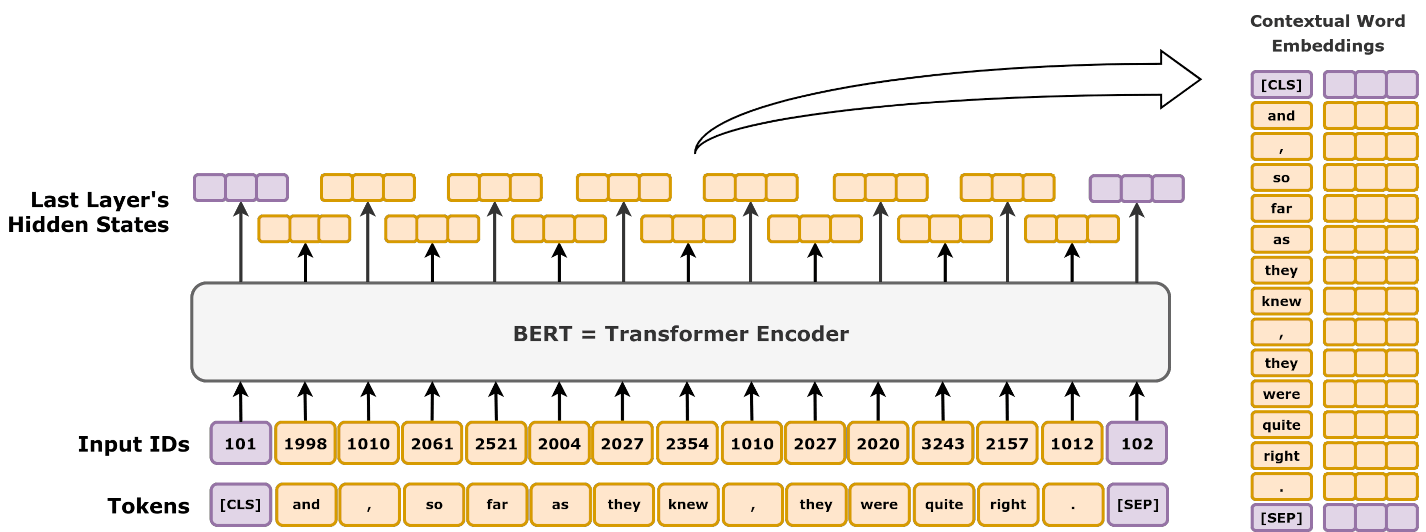

**High-level schematic diagram of BERT. It takes in a text, tokenizes it into a sequence of tokens, add in optional special tokens, and apply a Transformer encoder. The hidden states of the last layer can then be used as contextual word embeddings.**

## BERT Embeddings

BERTBASE uses three types of embeddings: **token type**, **position**, and **segment type**.  
(BERTLARGE is similar but larger in size.)

### Tokenizer
- BERT uses **WordPiece** tokenizer (sub-word strategy, similar to byte-pair encoding).  
- Vocabulary size: **30,000** tokens.  
- Any token not in the vocabulary is replaced with **[UNK]** ("unknown").

### Embedding Layer Components
1. **Token Type Embedding**
   - Converts a one-hot vector into a dense vector based on the token type.
2. **Position Embedding**
   - Captures the position of a token in the sequence.
   - Uses **absolute position embeddings**: each position maps to a real-valued vector, each dimension being a sinusoidal function of the position.
3. **Segment Type Embedding**
   - Vocabulary: **0 or 1**  
   - Type-0: tokens before the **[SEP]** token  
   - Type-1: tokens after the **[SEP]** token  
   - Produces a dense vector representing which text segment the token belongs to.

### Combined Embedding
- The three vectors (**token + position + segment**) are **added together**.  
- The combined vector is normalized using **LayerNorm**.  
- Output: a **768-dimensional vector** per token (for BERTBASE).

### Forward Pass
- These embeddings are passed through **12 Transformer encoder blocks**.  
- Final vectors are decoded back to the **30,000-dimensional vocabulary space** using a simple **affine transformation layer**.


```mermaid
flowchart TD
    %% Input
    A["Input Text"] --> B["WordPiece Tokenizer"]
    
    %% Embeddings
    B --> C1["Token Type Embedding"]
    B --> C2["Position Embedding"]
    B --> C3["Segment Type Embedding"]
    
    %% Combine and Normalize
    C1 --> D["Add & LayerNorm"]
    C2 --> D
    C3 --> D
    
    %% Output
    D --> E["768-dimensional Token Embeddings"]
    E --> F["Input to Transformer Encoder (12 Layers)"]

    %% Node colors for dark theme
    style A fill:#222222,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style B fill:#333333,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style C1 fill:#ff9800,stroke:#ffffff,stroke-width:1px,color:#000000
    style C2 fill:#ffc107,stroke:#ffffff,stroke-width:1px,color:#000000
    style C3 fill:#ffeb3b,stroke:#ffffff,stroke-width:1px,color:#000000
    style D fill:#8bc34a,stroke:#ffffff,stroke-width:1px,color:#000000
    style E fill:#03a9f4,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style F fill:#009688,stroke:#ffffff,stroke-width:1px,color:#ffffff


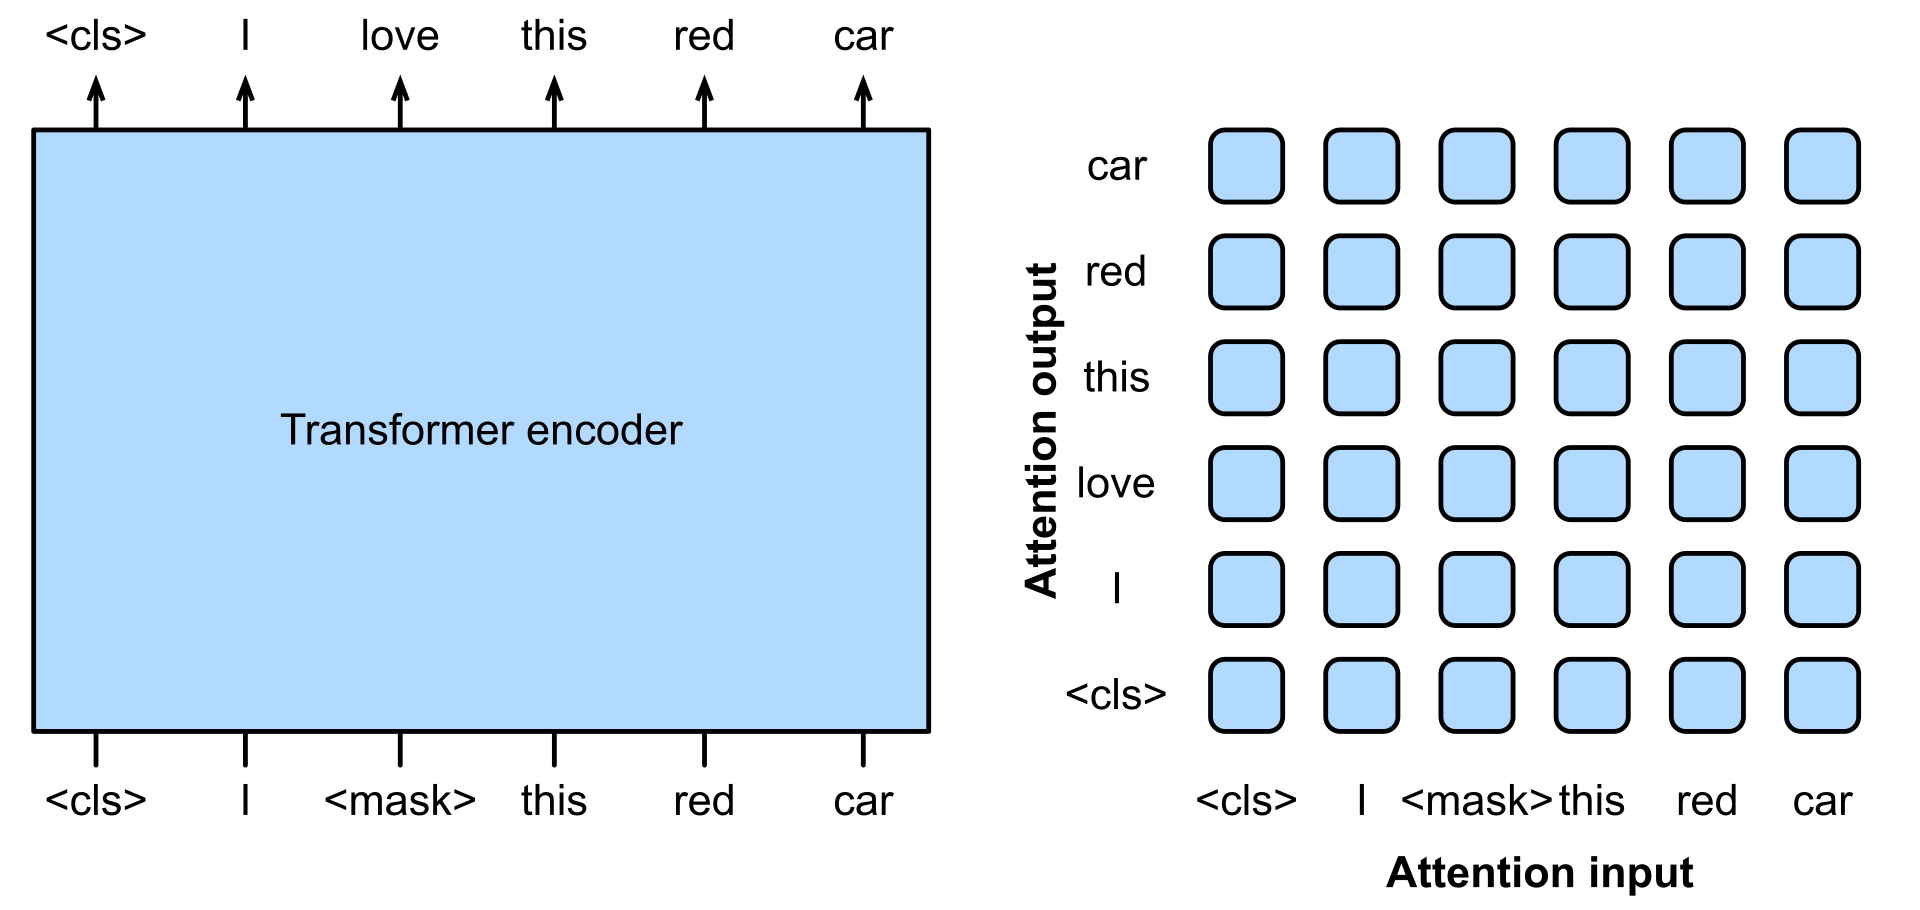

**Encoder-only attention is all-to-all.**

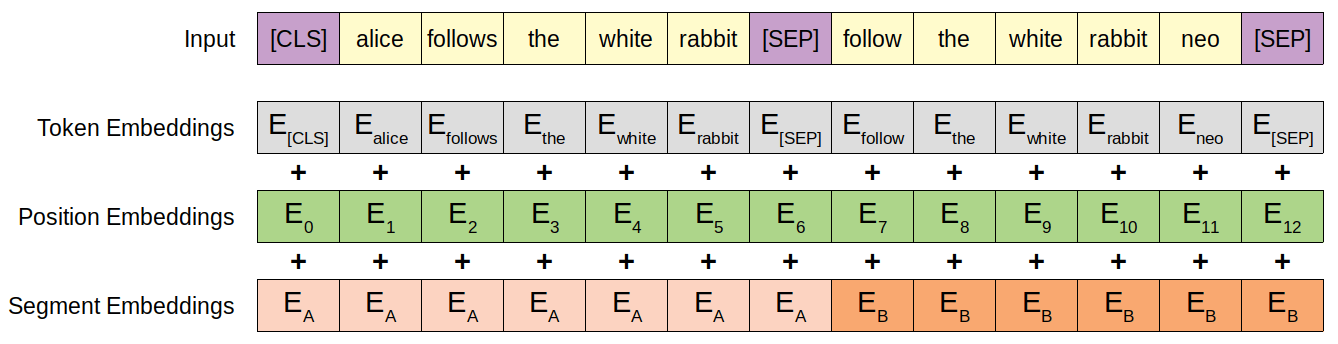

**The three kinds of embedding used by BERT: token type, position, and segment type.**

### BERT Architectural Family

The encoder stack of BERT has **two main parameters**:  

1. **L** – Number of layers (Transformer encoder blocks)  
2. **H** – Hidden size (dimension of embeddings / hidden states)  

Other fixed parameters:  
- **Number of self-attention heads** = H / 64  
- **Feed-forward (FFN) size / filter size** = 4 × H  

By varying L and H, we can create different versions of BERT.  

**Notes on terminology:**  
- **Feed-forward size** = **Filter size** = Number of dimensions in the middle layer of the FFN.  
- **Hidden size** = **Embedding size** = Number of real numbers used to represent a token.  

**Examples of BERT variants:**  
| Model       | Layers (L) | Hidden Size (H) | Notation  |
|------------|------------|----------------|-----------|
| BERTBASE   | 12         | 768            | 12L/768H |
| BERTLARGE  | 24         | 1024           | 24L/1024H |
| BERTTINY   | 2          | 128            | 2L/128H |


```mermaid

flowchart TD
    A["BERT Model"] --> B["Encoder Stack"]
    
    %% Encoder parameters
    B --> C["Number of Layers (L)"]
    B --> D["Hidden Size (H)"]
    B --> E["Self-Attention Heads = H/64"]
    B --> F["Feed-Forward Size = 4H"]

    %% Examples of BERT variants
    C --> G["BERTBASE: 12 Layers / 768 Hidden"]
    C --> H["BERTLARGE: 24 Layers / 1024 Hidden"]
    C --> I["BERTTINY: 2 Layers / 128 Hidden"]

    %% Colors suitable for dark theme
    style A fill:#222222,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style B fill:#333333,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style C fill:#444444,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style D fill:#555555,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style E fill:#666666,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style F fill:#777777,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style G fill:#1e88e5,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style H fill:#1e88e5,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style I fill:#1e88e5,stroke:#ffffff,stroke-width:1px,color:#ffffff


## BERT Pre-Training

BERT is pre-trained on **two tasks simultaneously**:

1. **Masked Language Modeling (MLM)**  
   - In MLM, some words in a sentence are **randomly masked** (replaced by `[MASK]`).  
   - BERT tries to **predict the original word** at the masked position.  
   - Example:  
     ```
     "The cat sat on the [MASK]."
     ```  
     BERT should predict: `"mat"`  
   - This helps BERT learn **bidirectional context**, understanding words based on both their **left and right neighbors**.

2. **Next Sentence Prediction (NSP)**  
   - In NSP, BERT is given **two sentences** and must predict if the **second sentence logically follows the first**.  
   - Example:  
     ```
     Sentence 1: "The cat sat on the mat."  
     Sentence 2: "It was a sunny day."
     ```  
     BERT decides if Sentence 2 is a valid continuation of Sentence 1.  
   - This helps BERT **understand relationships between sentences**, which is important for tasks like **question answering** or **document classification**.


<div align="center">

<b style="color:#00bcd4; font-size:20px; border:2px solid #00bcd4; padding:6px 14px; border-radius:8px;">
BERT Pre-Training Tasks: Masked Language Modeling & Next Sentence Prediction
</b>
</div>



```mermaid
flowchart TD
    %% Input
    A["Input Sentence Pair"] --> B["Tokenization + Special Tokens (CLS, SEP, MASK)"]

    %% MLM Task
    B --> C["Masked Language Modeling (MLM)"]
    C --> D["Predict Masked Tokens (e.g., [MASK] → 'mat')"]

    %% NSP Task
    B --> E["Next Sentence Prediction (NSP)"]
    E --> F["Classify if Sentence B follows Sentence A"]

    %% Output
    D --> G["BERT Learns Bidirectional Context"]
    F --> G

    %% Styles - Dark Theme
    style A fill:#222222,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style B fill:#333333,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style C fill:#444444,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style D fill:#555555,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style E fill:#444444,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style F fill:#555555,stroke:#ffffff,stroke-width:1px,color:#ffffff
    style G fill:#00897b,stroke:#ffffff,stroke-width:1px,color:#ffffff
```

### 🧩 Masked Language Modeling (MLM)

In the **Masked Language Modeling** task, BERT learns to predict missing words in a sentence using their context.  
During training, **15% of the tokens** in each input sequence are randomly selected for prediction.

#### Masking Strategy
For each selected token:
- **80%** → replaced with `[MASK]` token  
- **10%** → replaced with a **random word**  
- **10%** → **kept unchanged**

This mixed strategy prevents **dataset shift**, meaning the model won’t depend on the presence of `[MASK]` tokens during real-world use (since actual inputs don’t contain them).

#### Example
Input sentence:  
> “my dog is cute”

Tokenized as → `my₁ dog₂ is₃ cute₄`

Possible transformations:
1. 80% chance → `my dog is [MASK]`  
2. 10% chance → `my dog is happy`  
3. 10% chance → `my dog is cute`

After this, BERT predicts the correct token (“cute”) by analyzing the context around it.

---

<div align="center">

<b style="color:#00bcd4; font-size:20px; border:2px solid #00bcd4; padding:6px 14px; border-radius:8px;">
BERT Masked Language Modeling (MLM) Process
</b>

```mermaid
flowchart TD
    A["Input Sentence: 'my dog is cute'"] --> B["Randomly Select 15% Tokens"]
    B --> C["Token 4 ('cute') Selected"]
    C --> D1["80% → Replace with [MASK]: 'my dog is [MASK]'"]
    C --> D2["10% → Replace with Random Word: 'my dog is happy'"]
    C --> D3["10% → Keep Original: 'my dog is cute'"]
    D1 & D2 & D3 --> E["Feed Input to BERT Encoder"]
    E --> F["BERT Predicts the Masked Word 'cute' from Context"]

    %% Dark Theme Colors
    style A fill:#222,stroke:#fff,stroke-width:1px,color:#fff
    style B fill:#333,stroke:#fff,stroke-width:1px,color:#fff
    style C fill:#444,stroke:#fff,stroke-width:1px,color:#fff
    style D1 fill:#555,stroke:#fff,stroke-width:1px,color:#fff
    style D2 fill:#555,stroke:#fff,stroke-width:1px,color:#fff
    style D3 fill:#555,stroke:#fff,stroke-width:1px,color:#fff
    style E fill:#666,stroke:#fff,stroke-width:1px,color:#fff
    style F fill:#009688,stroke:#fff,stroke-width:1px,color:#fff


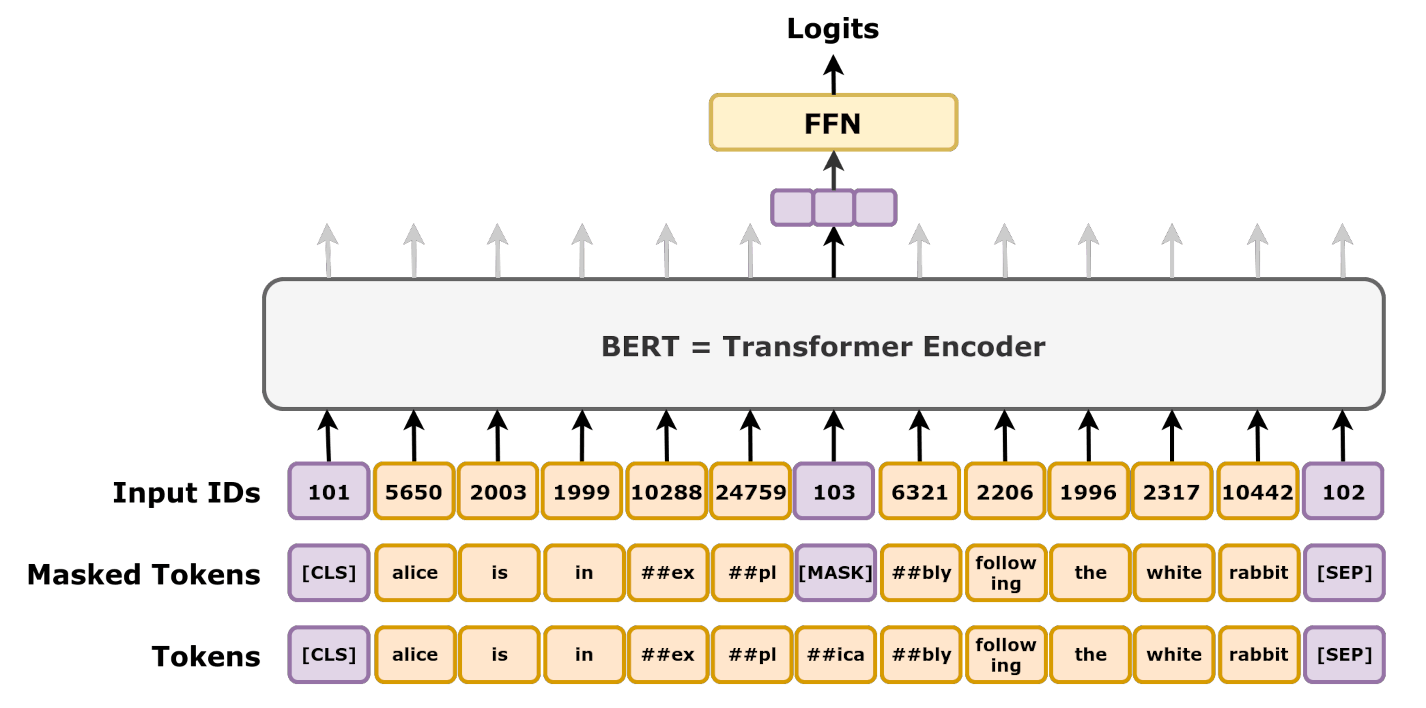

**The masked language modeling task**

### 🔗 Next Sentence Prediction (NSP)

The **Next Sentence Prediction** (NSP) task helps BERT learn how sentences relate to each other — an essential ability for understanding context in longer texts, such as in **question answering** or **reading comprehension**.

#### Objective
Given two sentences, BERT predicts whether the **second sentence logically follows** the first one in the original text.

It outputs one of two labels:
- **[IsNext]** → The second sentence follows the first one in context  
- **[NotNext]** → The second sentence is unrelated

#### Input Format
- A **special token `[CLS]`** is added at the beginning (used for classification).  
- The two sentences are **separated by `[SEP]`** tokens.  
- Example input:  
  `[CLS] Sentence A [SEP] Sentence B [SEP]`

#### How It Works
- Both sentences are passed through BERT’s encoder.  
- The **final hidden vector of `[CLS]`** represents the combined meaning of both sentences.  
- This vector goes into a **linear classifier**, which predicts either `[IsNext]` or `[NotNext]`.

#### Example
| Input | Output |
|:------|:-------|
| `[CLS] my dog is cute [SEP] he likes playing [SEP]` | ✅ [IsNext] |
| `[CLS] my dog is cute [SEP] how do magnets work [SEP]` | ❌ [NotNext] |

---

<div align="center">

<b style="color:#00bcd4; font-size:20px; border:2px solid #00bcd4; padding:6px 14px; border-radius:8px;">
BERT Next Sentence Prediction (NSP) Process
</b>

```mermaid
flowchart TD
    A["Input: [CLS] Sentence A [SEP] Sentence B [SEP]"] --> B["Token Embeddings + Segment IDs"]
    B --> C["Transformer Encoder (Contextual Understanding)"]
    C --> D["Extract [CLS] Token Representation"]
    D --> E["Feed to Linear Classifier"]
    E --> F["Prediction: [IsNext] or [NotNext]"]

    %% Dark Theme Colors
    style A fill:#222,stroke:#fff,stroke-width:1px,color:#fff
    style B fill:#333,stroke:#fff,stroke-width:1px,color:#fff
    style C fill:#444,stroke:#fff,stroke-width:1px,color:#fff
    style D fill:#555,stroke:#fff,stroke-width:1px,color:#fff
    style E fill:#666,stroke:#fff,stroke-width:1px,color:#fff
    style F fill:#009688,stroke:#fff,stroke-width:1px,color:#fff


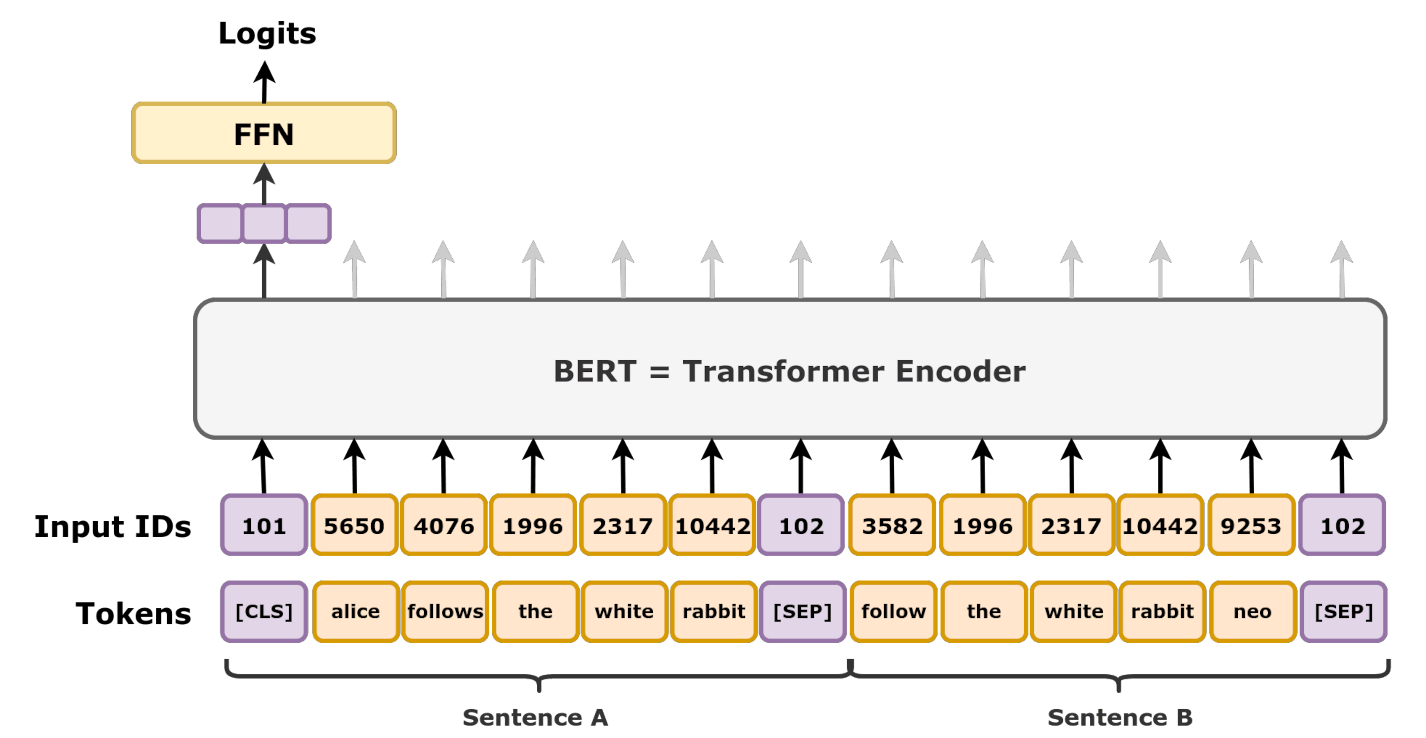

**The next sentence prediction task**

### 🎯 Fine-Tuning BERT

After pre-training, **BERT** serves as a **general-purpose language model** that can be fine-tuned for a wide range of **NLP tasks** with **smaller datasets** and **less training time**.

Fine-tuning adjusts the pre-trained model’s parameters slightly to specialize it for specific downstream applications such as:

- 🗣️ **Sentiment Classification** (e.g., positive/negative reviews)  
- 📚 **Sentence Classification** (e.g., topic or intent detection)  
- ❓ **Question Answering** (e.g., SQuAD dataset)  
- 🧠 **Multiple-Choice Reasoning** (e.g., SWAG dataset)  
- 🏷️ **Part-of-Speech Tagging** (e.g., labeling words with grammatical roles)

---

#### 🧩 How Fine-Tuning Works

1. Start with the **pre-trained BERT model**.  
2. Replace the **pre-training task heads** (like MLM and NSP) with a **new task-specific output layer**.  
3. Feed the **[CLS] token’s final vector** into this layer for classification tasks.  
4. Train the entire model (including BERT weights) for a few epochs on the new dataset.

> In the original BERT paper, fine-tuning BERT-Large for just **1 hour on a Cloud TPU** achieved **state-of-the-art** results on:
> - **GLUE Benchmark** (9 NLP tasks)  
> - **SQuAD v1.1 & v2.0** (Question Answering)  
> - **SWAG** (Reasoning benchmark)

---

#### 🧠 Important Note
The final output layer in fine-tuning is often called the **"pooler layer"**, similar to global pooling in vision models.  
However, it simply uses the **[CLS] token representation** (the first token’s embedding) for prediction and discards the rest.

---

<div align="center">

<b style="color:#ffb300; font-size:20px; border:2px solid #ffb300; padding:6px 14px; border-radius:8px;">
BERT Fine-Tuning Process for Downstream Tasks
</b>

```mermaid
flowchart TD
    A["Pre-trained BERT Model"] --> B["Input: Task-Specific Text (e.g., QA, Sentiment)"]
    B --> C["Tokenizer + Embeddings"]
    C --> D["Transformer Encoder (Contextual Representations)"]
    D --> E["Extract [CLS] Token Embedding"]
    E --> F["Add Task-Specific Output Layer"]
    F --> G["Fine-Tune Entire Model on Target Dataset"]
    G --> H["Final Predictions (e.g., Label, Answer, Class)"]

    %% Dark Theme Colors
    style A fill:#222,stroke:#fff,stroke-width:1px,color:#fff
    style B fill:#333,stroke:#fff,stroke-width:1px,color:#fff
    style C fill:#444,stroke:#fff,stroke-width:1px,color:#fff
    style D fill:#555,stroke:#fff,stroke-width:1px,color:#fff
    style E fill:#666,stroke:#fff,stroke-width:1px,color:#fff
    style F fill:#777,stroke:#fff,stroke-width:1px,color:#fff
    style G fill:#888,stroke:#fff,stroke-width:1px,color:#fff
    style H fill:#4caf50,stroke:#fff,stroke-width:1px,color:#fff


### ⚖️ Difference Between Pre-training and Fine-tuning in BERT

| Aspect | **Pre-training Phase** | **Fine-tuning Phase** |
|:--|:--|:--|
| **Goal** | Learn general language understanding | Adapt to a specific downstream task |
| **Tasks Used** | Masked Language Modeling (MLM) and Next Sentence Prediction (NSP) | Sentiment Analysis, Question Answering, Classification, etc. |
| **Data Type** | Large, general text corpus (Wikipedia + BookCorpus) | Small, task-specific labeled dataset |
| **Input Format** | `[CLS] Sentence A [SEP] Sentence B [SEP]` | Same input format (depending on task) |
| **Parameters Updated** | All model parameters from scratch | All parameters fine-tuned slightly |
| **Training Duration** | Days or weeks on powerful hardware | Hours on a single GPU or TPU |
| **Output** | General language model (contextual embeddings) | Task-optimized model (predictions or labels) |
| **Example** | Predict missing words or sentence order | Predict sentiment or answer a question |

---

<div align="center">

<b style="color:#ffb300; font-size:20px; border:2px solid #ffb300; padding:6px 14px; border-radius:8px;">
BERT: From Pre-training to Fine-tuning
</b>

```mermaid
flowchart LR
    A["Pre-training Phase"] -->|Learns General Language Patterns| B["Fine-tuning Phase"]
    B -->|Adapts to Specific NLP Tasks| C["Task-Optimized BERT Model"]

    %% Styling for dark theme
    style A fill:#03a9f4,stroke:#fff,stroke-width:1px,color:#fff
    style B fill:#8bc34a,stroke:#fff,stroke-width:1px,color:#fff
    style C fill:#4caf50,stroke:#fff,stroke-width:1px,color:#fff


## 🌱 Variants and Fine-tuned Models Derived from BERT

After BERT’s success, several **improved and task-optimized variants** were developed.  
Each focused on specific limitations of the original model such as speed, size, or training efficiency.

---

### 🔹 RoBERTa (Robustly Optimized BERT Approach)
- **Developer:** Facebook AI (2019)  
- **Improvement:** Removed the *Next Sentence Prediction (NSP)* objective.  
- **Enhancement:** Trained on larger mini-batches, more data, and longer sequences.  
- **Effect:** Achieved better performance on GLUE and SQuAD benchmarks.  
- **Key Idea:** BERT was undertrained — RoBERTa fixed that by *training longer and smarter*.

---

### 🔹 DistilBERT
- **Developer:** Hugging Face (2019)  
- **Improvement:** Lightweight, 40% smaller and 60% faster than BERT.  
- **Technique:** *Knowledge Distillation* — a smaller “student” network learns from a larger “teacher” BERT model.  
- **Effect:** Retains ~97% of BERT’s performance while being more efficient.  
- **Key Use:** Deployed in production systems needing fast inference.

---

### 🔹 ALBERT (A Lite BERT)
- **Developer:** Google Research & Toyota Technological Institute (2019)  
- **Improvement:** Reduced parameters by factorization and parameter sharing.  
- **Technique:**  
  - Factorized embedding parameterization (decoupling vocabulary and hidden size).  
  - Cross-layer parameter sharing.  
- **Effect:** Much smaller memory footprint without performance loss.  
- **Key Idea:** Same architecture as BERT, but *more efficient in memory and speed.*

---

### 🔹 TinyBERT & MiniBERT
- **Goal:** Further compress BERT for on-device NLP.  
- **Method:** Distillation and pruning while retaining task-specific accuracy.  
- **Use Case:** Mobile devices, chatbots, and low-resource environments.

---

### 🔹 SpanBERT
- **Improvement:** Predicts *spans* of text (multiple consecutive tokens) instead of single masked words.  
- **Effect:** Enhanced understanding of multi-word expressions and entity-level relationships.  
- **Use Case:** Information extraction and question answering.

---

### ⚙️ Summary Comparison Table

| Model | Key Developer | Core Improvement | Size / Speed | Notes |
|:--|:--|:--|:--|:--|
| **BERT (Base)** | Google | Bidirectional training, MLM + NSP | 110M params | Original architecture |
| **RoBERTa** | Facebook | Removed NSP, better training | Same size | Stronger performance |
| **DistilBERT** | Hugging Face | Knowledge distillation | 60% faster | Lightweight version |
| **ALBERT** | Google & TTI | Parameter sharing | Smaller memory | Efficient large model |
| **TinyBERT** | Huawei | Task-specific distillation | Very small | Edge deployment |
| **SpanBERT** | Facebook | Span-level masking | Moderate | Better for QA/NER |

---

<div align="center">

<b style="color:#ff4081; font-size:20px; border:2px solid #ff4081; padding:6px 14px; border-radius:8px;">
BERT Evolution Map
</b>

```mermaid
graph LR
    A["BERT (2018)"] --> B["RoBERTa (2019)"]
    A --> C["DistilBERT (2019)"]
    A --> D["ALBERT (2019)"]
    A --> E["TinyBERT (2020)"]
    A --> F["SpanBERT (2019)"]

    %% Styling for nodes
    style A fill:#03a9f4,stroke:#fff,stroke-width:1px,color:#fff
    style B fill:#8bc34a,stroke:#fff,stroke-width:1px,color:#fff
    style C fill:#ff9800,stroke:#fff,stroke-width:1px,color:#fff
    style D fill:#9c27b0,stroke:#fff,stroke-width:1px,color:#fff
    style E fill:#f44336,stroke:#fff,stroke-width:1px,color:#fff
    style F fill:#00bcd4,stroke:#fff,stroke-width:1px,color:#fff


## 🧱 BERT Architectural Family

BERT defines a family of models that differ mainly by **depth (L)** and **hidden size (H)**.  
Each model in the family uses the same encoder design — only the scale varies.

---

### 🔹 Scaling Parameters

| Model | Layers (L) | Hidden Size (H) | Attention Heads (A = H/64) | Feed-Forward Size (4H) | Parameters |
|:--|:--:|:--:|:--:|:--:|:--:|
| **BERT-Tiny** | 2 | 128 | 2 | 512 | ~4.4M |
| **BERT-Mini** | 4 | 256 | 4 | 1024 | ~11M |
| **BERT-Small** | 4 | 512 | 8 | 2048 | ~29M |
| **BERT-Medium** | 8 | 512 | 8 | 2048 | ~41M |
| **BERT-Base** | 12 | 768 | 12 | 3072 | ~110M |
| **BERT-Large** | 24 | 1024 | 16 | 4096 | ~340M |

🧩 *Note:*  
- The hidden size (**H**) determines embedding and model width.  
- Feed-forward layers are always **4H** wide.  
- Attention heads scale proportionally (**H / 64** rule).  

---

<div align="center">

<b style="color:#ff4081; font-size:20px; border:2px solid #ff4081; padding:6px 14px; border-radius:8px;">
BERT Model Family Hierarchy
</b>

```mermaid
flowchart TD
    A["BERT-Tiny (2L / 128H)"] --> B["BERT-Mini (4L / 256H)"]
    B --> C["BERT-Small (4L / 512H)"]
    C --> D["BERT-Medium (8L / 512H)"]
    D --> E["BERT-Base (12L / 768H)"]
    E --> F["BERT-Large (24L / 1024H)"]

    %% Styling
    style A fill:#263238,stroke:#fff,stroke-width:1px,color:#fff
    style B fill:#37474f,stroke:#fff,stroke-width:1px,color:#fff
    style C fill:#455a64,stroke:#fff,stroke-width:1px,color:#fff
    style D fill:#546e7a,stroke:#fff,stroke-width:1px,color:#fff
    style E fill:#607d8b,stroke:#fff,stroke-width:1px,color:#fff
    style F fill:#78909c,stroke:#fff,stroke-width:1px,color:#fff


## 🧩 Cost and Interpretation of BERT

### 💰 Cost of Training

BERT was trained on two major text corpora:
- **BookCorpus** — 800 million words  
- **English Wikipedia** — 2.5 billion words (filtered to remove lists, tables, and headers)

| Model | Hardware | Duration | TPU Chips | Estimated Cost | Dataset Size |
|:------|:----------|:----------|:-----------|:----------------|:---------------|
| **BERTBASE** | 4 Cloud TPUs | 4 days | 16 | ≈ **$500** | 3.3B words |
| **BERTLARGE** | 16 Cloud TPUs | 4 days | 64 | — | 3.3B words |

> ⚙️ **Note:** Despite its relatively low training cost for research-scale hardware, the computational intensity and TPU dependency make BERT expensive to reproduce for small institutions.

---

### 🧠 Interpretation — Understanding BERT’s Inner Workings

The emergence of BERT and similar models like **ELMo** and **GPT-2** gave rise to a new research domain called **“BERTology”** — focused on interpreting what these models actually learn.

#### 🔍 Key Areas of Study
- **Input-output behavior:** Analyzing how BERT’s predictions change with carefully designed input sequences.  
- **Probing classifiers:** Evaluating what linguistic or semantic information is encoded in internal representations.  
- **Attention patterns:** Interpreting how attention weights reflect syntactic and semantic relationships within text.

#### 🧩 Why BERT Performs Well
BERT’s high performance is mainly attributed to its **bidirectional Transformer architecture**, which learns context from **both left and right sides** of a word.  
For example:
- “I feel **fine** today” → *fine = healthy*  
- “She has **fine** blond hair” → *fine = delicate*  

This dual-directional understanding enables BERT to capture deep contextual nuances.

---

### ⚠️ Limitations of Bidirectional Encoding

While bidirectionality improves comprehension, it introduces practical drawbacks:

| Limitation | Description |
|:------------|:-------------|
| **No text generation** | BERT is an **encoder-only** model — it cannot generate text or perform prompting like GPT. |
| **Dataset shift** | If BERT is used to fill long missing spans (e.g., “Today I went to [MASK] [MASK] [MASK]...”), it performs poorly because it was never trained on such heavy masking. |
| **High compute for generative adaptation** | Turning BERT into a text generator requires complex masking and decoding mechanisms, increasing computational cost. |

---

### 🧠 Insight

> BERT’s strength lies in **understanding**, not **generation**.  
> Its bidirectional encoder provides deep semantic comprehension but limits its ability to perform open-ended text generation.  
> Later models like **GPT** (decoder-only) and **T5/BART** (encoder-decoder) emerged to fill this gap.


## 📜 History of BERT

- **Authors:** Jacob Devlin, Ming-Wei Chang, Kenton Lee, and Kristina Toutanova (Google AI)  
- **Origin:** BERT’s design builds upon previous advances in **pre-training contextual representations**, including:
  - Semi-supervised sequence learning  
  - Generative pre-training  
  - ELMo  
  - ULMFit  

### 🔹 Key Innovations
- **Deeply bidirectional:** Unlike previous models, BERT reads text **both left-to-right and right-to-left**, capturing richer context.  
- **Contextual embeddings:** Each word receives a vector **dependent on its sentence context**.  
  - Example: The word “running”:
    - In “He is running a company” → contextual embedding reflects business context  
    - In “He is running a marathon” → contextual embedding reflects physical activity  
- **Unsupervised pre-training:** BERT learns from **plain text corpora** without any labeled data.

### 🌐 BERT in Google Search
- **Oct 25, 2019:** Google started using BERT for **English search queries** in the US.  
- **Dec 9, 2019:** BERT adopted for **70+ languages**.  
- **Oct 2020:** Nearly **all English-based search queries** processed using BERT models.

> ⚡ Insight: BERT’s contextual understanding transformed NLP applications, setting a new standard for search, language comprehension, and downstream NLP tasks.


```mermaid
flowchart TD
    %% Title
    subgraph TitleBox["📜 BERT History Timeline"]
        style TitleBox fill:#222222,stroke:#ffffff,stroke-width:2px,color:#ffffff,font-weight:bold
    end

    %% Timeline nodes with emojis
    A["🚀 2018: BERT introduced by Google AI<br>(Jacob Devlin, Ming-Wei Chang, Kenton Lee, Kristina Toutanova)"]
    B["🧠 2018: Based on pre-training ideas from ELMo, ULMFit, generative pre-training"]
    C["🇺🇸 2019-10-25: Applied to English Google Search queries in the US"]
    D["🌐 2019-12-09: Adopted for 70+ languages in Google Search"]
    E["🔍 2020-10: Almost all English-based search queries processed by BERT"]

    %% Timeline flow
    TitleBox --> A --> B --> C --> D --> E

    %% Node styles for dark theme
    style A fill:#ff9800,stroke:#ffffff,stroke-width:1px,color:#000000
    style B fill:#ffc107,stroke:#ffffff,stroke-width:1px,color:#000000
    style C fill:#03a9f4,stroke:#ffffff,stroke-width:1px,color:#000000
    style D fill:#8bc34a,stroke:#ffffff,stroke-width:1px,color:#000000
    style E fill:#e91e63,stroke:#ffffff,stroke-width:1px,color:#000000


```mermaid
flowchart TD
    %% Title
    subgraph TitleBox["🧩 BERT Variants Timeline"]
        style TitleBox fill:#222222,stroke:#ffffff,stroke-width:2px,color:#ffffff,font-weight:bold
    end

    %% Variants nodes
    A["2019: RoBERTa<br>Engineering improvements, removed NSP, larger batch size"]
    B["2019: XLM-RoBERTa<br>Multilingual RoBERTa model"]
    C["2019: DistilBERT<br>60% parameters, preserves 95% performance"]
    D["2019: TinyBERT<br>28% parameters, task-specific distillation"]
    E["2019: ALBERT<br>Shared parameters, sentence-order prediction (SOP) task"]
    F["2020: ELECTRA<br>GAN-style token replacement, discriminative training"]
    G["2020: DeBERTa<br>Disentangled attention, separate token & position encodings"]

    %% Timeline flow
    TitleBox --> A --> B --> C --> D --> E --> F --> G

    %% Node styles for dark theme
    style A fill:#ff9800,stroke:#ffffff,stroke-width:1px,color:#000000
    style B fill:#ffc107,stroke:#ffffff,stroke-width:1px,color:#000000
    style C fill:#03a9f4,stroke:#ffffff,stroke-width:1px,color:#000000
    style D fill:#8bc34a,stroke:#ffffff,stroke-width:1px,color:#000000
    style E fill:#e91e63,stroke:#ffffff,stroke-width:1px,color:#000000
    style F fill:#9c27b0,stroke:#ffffff,stroke-width:1px,color:#000000
    style G fill:#00bcd4,stroke:#ffffff,stroke-width:1px,color:#000000


## 🔹 BERT Variants

The BERT models were highly influential and inspired several important variants. Each variant builds upon the **encoder-only architecture of BERT** but introduces optimizations for **efficiency, multilingual support, or task-specific improvements**.

| Variant | Year | Key Idea | Core Changes / Optimization | Developer |
|---------|------|----------|----------------------------|-----------|
| **RoBERTa** | 2019 | Robust training improvements | Preserves BERT architecture (slightly larger, 355M parameters), removes next sentence prediction (NSP), uses larger batch sizes and optimized hyperparameters | Facebook AI |
| **XLM-RoBERTa** | 2019 | Multilingual support | First large-scale multilingual language model, based on RoBERTa | Facebook AI |
| **DistilBERT** | 2019 | Model compression | Distills BERTBASE to 60% of parameters (66M), retains ~95% performance | Hugging Face |
| **TinyBERT** | 2019 | On-device NLP | Further compression to 28% of parameters, task-specific distillation | Huawei |
| **ALBERT** | 2019 | Lightweight & efficient | Shared parameters across layers, independently varies hidden and embedding sizes, replaces NSP with Sentence Order Prediction (SOP) | Google & TTI |
| **ELECTRA** | 2020 | Generative adversarial MLM | Uses a small generator model to produce token replacements; a discriminator identifies replaced tokens, improving pre-training efficiency | Google Research |
| **DeBERTa** | 2020 | Disentangled attention | Keeps positional and token encodings separate; computes three distinct attention matrices (content-to-content, content-to-position, position-to-content); improves contextual understanding | Microsoft Research |

### 🧠 Key Insights
- All BERT variants **share the same encoder stack**:  
  `Multi-Head Attention → Add & Norm → Feed Forward → Add & Norm`
- Differences lie in **depth, width, training strategy, and task optimizations**.
- **DeBERTa** introduces a more sophisticated attention mechanism by separating token and positional encodings, computing three attention matrices, and including absolute positional encoding in the final layer.
- Variants like **RoBERTa and ALBERT** improve **efficiency and robustness**, while **DistilBERT and TinyBERT** focus on **model compression** for resource-constrained environments.



In [8]:
%%writefile bert_model.py
import torch
import torch.nn as nn


class BERTEmbedding(nn.Module):
    def __init__(self,
                 vocab_size,
                 n_segments,
                 max_len,
                 embed_dim,
                 dropout):
        super().__init__()
        self.tok_embed = nn.Embedding(vocab_size, embed_dim)
        self.seg_embed = nn.Embedding(n_segments, embed_dim)
        self.pos_embed = nn.Embedding(max_len, embed_dim)
        self.drop = nn.Dropout(dropout)
        self.max_len = max_len

    def forward(self, seq, seg):
        """
        seq: [batch_size, seq_len]
        seg: [batch_size, seq_len]
        """
        batch_size, seq_len = seq.size()
        device = seq.device

        # Create position indices for each token
        pos_inp = torch.arange(seq_len, device=device).unsqueeze(0).repeat(batch_size, 1)

        # Sum of token, segment, and position embeddings
        embed_val = self.tok_embed(seq) + self.seg_embed(seg) + self.pos_embed(pos_inp)
        embed_val = self.drop(embed_val)
        return embed_val  # shape: [batch_size, seq_len, embed_dim]


class BERT(nn.Module):
    def __init__(self,
                 vocab_size,
                 n_segments,
                 max_len,
                 embed_dim,
                 n_layers,
                 attn_heads,
                 dropout):
        super().__init__()
        self.embedding = BERTEmbedding(vocab_size, n_segments, max_len, embed_dim, dropout)

        # ✅ Use batch_first=True to remove warning and improve performance
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=attn_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.encoder_block = nn.TransformerEncoder(self.encoder_layer, n_layers)

    def forward(self, seq, seg):
        """
        seq, seg: [batch_size, seq_len]
        """
        out = self.embedding(seq, seg)
        out = self.encoder_block(out)
        return out  # shape: [batch_size, seq_len, embed_dim]


if __name__ == "__main__":
    # ----- Hyperparameters -----
    VOCAB_SIZE = 30000
    N_SEGMENTS = 3
    MAX_LEN = 512
    EMBED_DIM = 768
    N_LAYERS = 12
    ATTN_HEADS = 12
    DROPOUT = 0.1

    # ----- Dummy Input -----
    batch_size = 2
    sample_seq = torch.randint(high=VOCAB_SIZE, size=[batch_size, MAX_LEN])
    sample_seg = torch.randint(high=N_SEGMENTS, size=[batch_size, MAX_LEN])

    # ----- Embedding Output -----
    embedding = BERTEmbedding(VOCAB_SIZE, N_SEGMENTS, MAX_LEN, EMBED_DIM, DROPOUT)
    embedding_tensor = embedding(sample_seq, sample_seg)
    print("🔹 Embedding Output Shape:", embedding_tensor.size())  # [batch, seq_len, embed_dim]

    # ----- BERT Model Output -----
    bert = BERT(VOCAB_SIZE, N_SEGMENTS, MAX_LEN, EMBED_DIM, N_LAYERS, ATTN_HEADS, DROPOUT)
    out = bert(sample_seq, sample_seg)
    print("🔸 BERT Model Output Shape:", out.size())  # [batch, seq_len, embed_dim]


Writing bert_model.py


In [9]:
!python bert_model.py


🔹 Embedding Output Shape: torch.Size([2, 512, 768])
🔸 BERT Model Output Shape: torch.Size([2, 512, 768])
